# 03 — Exploratory data analysis (Stage B)

Label structure and original-image properties of VizWiz-QualityIssues, before any modelling.
All analysis logic lives in `src/eda/`; this notebook only calls it and displays results.
It regenerates `reports/eda.md` and `reports/figures/eda_*.png`.

**Partitions:** train and val only. The test partition is never read during development.

**How to run:** from the `notebooks/` folder, with `DATA_DIR` pointing at the data directory
(defaults to `../data`). `DATA_DIR` must contain `annotations/{train,val}.json`. Part 2 also needs
`DATA_DIR/image_properties.csv`, produced by
`python scripts/extract_image_properties.py DATA_DIR`; without it, Part 2 is skipped.
No GPU needed.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

REPO_DIR = Path.cwd().parent if (Path.cwd().parent / "src").is_dir() else Path.cwd()
sys.path.insert(0, str(REPO_DIR))
DATA_DIR = Path(os.environ.get("DATA_DIR", REPO_DIR / "data"))
REPORT_PATH = REPO_DIR / "reports" / "eda.md"
FIGURES_DIR = REPO_DIR / "reports" / "figures"

from src.data.splits import MODELLED_FLAWS, get_splits
from src.eda import image_props as ip
from src.eda import labels as lb
from src.eda import report as rp

print("REPO_DIR:", REPO_DIR)
print("DATA_DIR:", DATA_DIR)
print("\n".join(rp.environment_lines()))

REPO_DIR: /content/drive/MyDrive/Masters/Sem 3/capstone/repo
DATA_DIR: /content/data


- Python 3.13.15 on Linux-6.6.122+-x86_64-with-glibc2.39
- RAM: 12.7 GB
- GPU: none (not needed: Stage B reads labels and image headers only)
- Seed: 42 (only randomness is the val/test split in src/data/splits.py)


In [2]:
splits = get_splits(DATA_DIR)
train = splits["train"]
print({name: len(splits[name]) for name in ("train", "val")})
sections = []  # (heading, markdown) pairs collected for reports/eda.md

def show(fig, name):
    rp.save(fig, FIGURES_DIR, name)
    display(fig)
    plt.close(fig)

def figure_link(name):
    return f"![{name}](figures/{name}.png)"

{'train': 23431, 'val': 3875}


## Part 1 — Labels

### 1.1 Prevalence at >=1 and >=2 votes
Train vs val should match closely; any gap would mean the partitions differ in kind.
UNREC is the unrecognizable vote (>=2 is the dataset authors' "poor image" definition).

,train >=1,train >=2,val >=1,val >=2
BLR,60.5,40.8,60.6,42.2
BRT,17.7,5.3,19.1,5.8
DRK,18.5,5.8,19.5,6.3
FRM,75.6,55.2,76.5,55.4
NON,72.7,48.4,71.7,47.3
OBS,13.9,3.6,14.3,3.5
OTH,8.0,0.8,8.0,0.6
ROT,28.6,17.0,28.7,17.1
UNREC,32.8,15.2,31.7,15.6


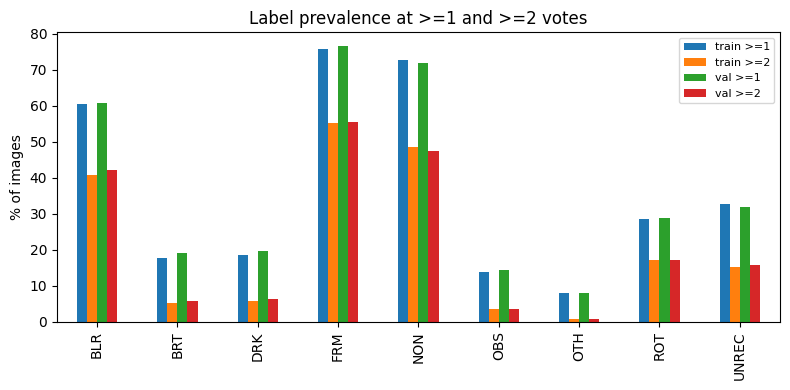

In [3]:
prevalence = lb.prevalence_table(splits)
display(prevalence)
show(rp.plot_prevalence(prevalence), "eda_prevalence")
sections.append(("Prevalence (% of images)",
                 rp.df_to_markdown(prevalence) + "\n\n" + figure_link("eda_prevalence")))

### 1.2 Co-occurrence (train, >=2 votes)
Cell [A, B] = P(B | A) in %. Lift = P(B | A) / P(B): above 1 means the pair occurs together more than chance.
Flaws that share a cause (e.g. low light -> long exposure -> motion blur) can make one flaw look
predictable "by proxy" from another flaw's features.

,BLR,BRT,DRK,FRM,OBS,ROT
BLR,100.0,8.4,7.2,64.6,5.6,16.9
BRT,64.3,100.0,9.5,61.6,8.2,13.4
DRK,50.5,8.6,100.0,48.1,6.1,10.9
FRM,47.7,5.9,5.1,100.0,4.6,19.1
OBS,63.6,12.1,9.9,71.0,100.0,12.6
ROT,40.4,4.2,3.7,61.9,2.7,100.0


,BLR,BRT,DRK,FRM,OBS,ROT
BLR,2.45,1.58,1.23,1.17,1.56,0.99
BRT,1.58,18.77,1.63,1.12,2.29,0.79
DRK,1.24,1.61,17.14,0.87,1.70,0.64
FRM,1.17,1.11,0.87,1.81,1.28,1.12
OBS,1.56,2.27,1.70,1.29,27.89,0.74
ROT,0.99,0.79,0.63,1.12,0.75,5.88


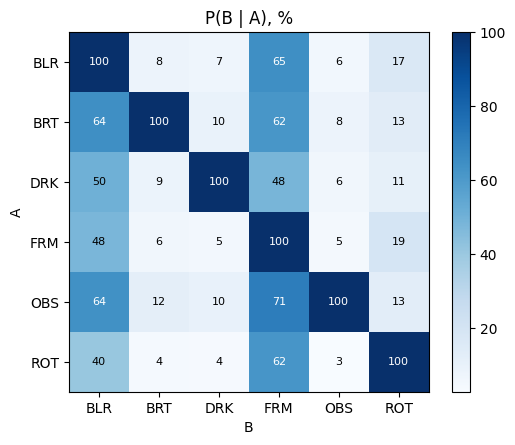

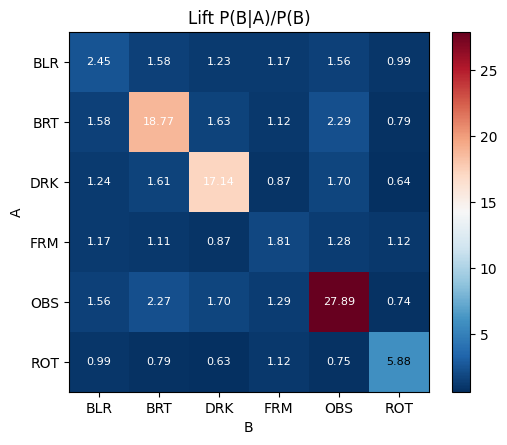

In [4]:
conditional, joint = lb.cooccurrence(train)
lift = lb.lift_matrix(train)
display(conditional, lift)
show(rp.plot_matrix(conditional, "P(B | A), %"), "eda_cooccurrence")
show(rp.plot_matrix(lift, "Lift P(B|A)/P(B)", fmt="{:.2f}", cmap="RdBu_r"), "eda_lift")
sections.append(("Flaw co-occurrence (train, >=2 votes)",
                 "P(B | A), %:\n\n" + rp.df_to_markdown(conditional)
                 + "\n\nLift P(B | A) / P(B):\n\n" + rp.df_to_markdown(lift)
                 + "\n\nJoint counts:\n\n" + rp.df_to_markdown(joint)
                 + "\n\n" + figure_link("eda_cooccurrence") + "\n\n" + figure_link("eda_lift")))

### 1.3 Vote distributions and annotator agreement (train)
Fleiss' kappa per label from the 5-rater vote counts (1 = perfect agreement, 0 = chance level).
"borderline 2-3 %" = images whose >=2 label would flip with a single rater changing their mind.
A preliminary view; the full human ceiling is Stage G.

,0,1,2,3,4,5
BLR,39.5,19.8,12.2,10.5,10.0,8.1
BRT,82.3,12.4,3.1,1.3,0.7,0.3
DRK,81.5,12.6,3.0,1.3,1.0,0.6
FRM,24.4,20.4,19.9,17.9,12.5,4.9
OBS,86.1,10.4,1.9,0.8,0.6,0.3
ROT,71.4,11.6,6.6,5.8,3.5,1.1
UNREC,67.2,17.6,6.1,3.7,3.1,2.3


,fleiss_kappa,unanimous %,borderline 2-3 %,positive >=2 %
BLR,0.406,47.591,22.654,40.767
BRT,0.222,82.579,4.336,5.326
DRK,0.271,82.066,4.276,5.834
FRM,0.238,29.341,37.736,55.200
OBS,0.228,86.304,2.702,3.585
ROT,0.379,72.553,12.377,17.012
UNREC,0.371,69.489,9.825,15.185


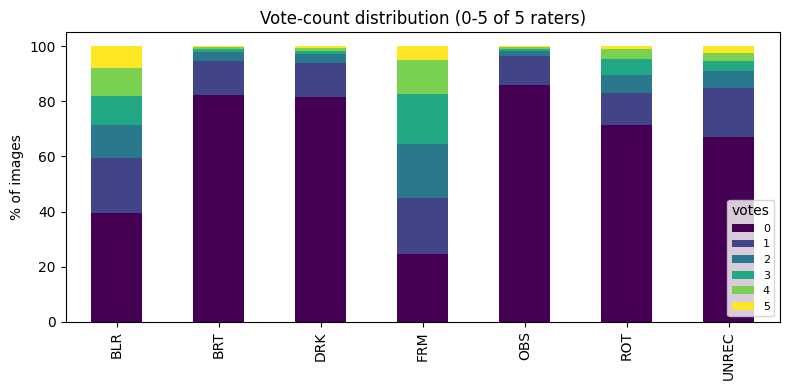

In [5]:
votes_dist = lb.vote_distribution(train)
agreement = lb.agreement_table(train)
display(votes_dist, agreement)
show(rp.plot_vote_distribution(votes_dist), "eda_votes")
sections.append(("Vote distributions (train, % of images)",
                 rp.df_to_markdown(votes_dist) + "\n\n" + figure_link("eda_votes")))
sections.append(("Annotator agreement (train)", rp.df_to_markdown(agreement)))

### 1.4 Flaws and recognisability (train)
Which flaws actually make an image unusable, and does unusability grow with the number of flaws?

In [6]:
by_count = lb.unrecognisable_by_flaw_count(train)
by_flaw = lb.unrecognisable_by_flaw(train)
display(by_count, by_flaw)
sections.append(("Unrecognisable rate by number of flaws (train, >=2 votes)",
                 rp.df_to_markdown(by_count)))
sections.append(("Unrecognisable rate by flaw (train, >=2 votes)", rp.df_to_markdown(by_flaw)))

,n,unrecognisable_pct
n_flaws,,
0,5469,2.0
1,8704,11.4
2,6877,22.9
3,2080,35.3
4,277,47.7
5,23,52.2
6,1,100.0


,n with flaw,unrec % | flaw,unrec % | no flaw,ratio
BLR,9552.0,26.6,7.3,3.64
BRT,1248.0,41.6,13.7,3.04
DRK,1367.0,48.0,13.2,3.65
FRM,12934.0,19.2,10.2,1.88
OBS,840.0,48.1,14.0,3.44
ROT,3986.0,8.4,16.6,0.51


## Part 2 — Original-image properties

Read from the original zips by `scripts/extract_image_properties.py` (headers only, raw pixel
dimensions, no EXIF rotation applied).

In [7]:
props_path = DATA_DIR / "image_properties.csv"
props = None
if props_path.exists():
    props = ip.load_properties(props_path)
    props = props[props["partition"].isin(["train", "val"])]
    print(props["partition"].value_counts().to_dict())
else:
    print(f"{props_path} not found - Part 2 skipped. Run scripts/extract_image_properties.py first.")

{'train': 23431, 'val': 3875}


### 2.1 Native resolution -> classical@512 decision
Pre-registered rule (docs/decisions.md): keep 512 unless more than 10% of originals have a long edge
below 512 (they would be upsampled, which smooths them and fakes blur).

,long edge (px)
p0,13
p1,324
p5,480
p10,648
p25,1296
p50,1296
p75,1632
p100,3264


{'long edge < 224 %': np.float64(0.34), 'long edge < 512 %': np.float64(9.32)}

KEEP 224: 0.3% of originals below it (limit 10%)
KEEP 512: 9.3% of originals below it (limit 10%)


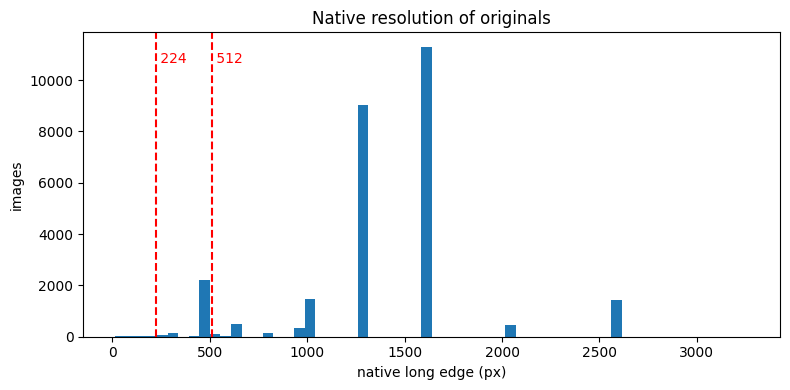

In [8]:
if props is not None:
    percentiles, below = ip.resolution_summary(props)
    verdicts = [ip.resolution_verdict(props, r)[1] for r in ip.CLASSICAL_RESOLUTIONS]
    display(percentiles.to_frame("long edge (px)"), below)
    for v in verdicts:
        print(v)
    show(rp.plot_long_edge(props), "eda_long_edge")
    sections.append(("Native resolution (train + val)",
                     rp.df_to_markdown(percentiles.to_frame("long edge (px)"))
                     + "\n\n" + "\n".join(f"- {k}: {v}" for k, v in below.items())
                     + "\n\nPre-registered upsampling rule:\n\n"
                     + "\n".join(f"- {v}" for v in verdicts)
                     + "\n\n" + figure_link("eda_long_edge")))

### 2.2 Aspect ratio and file size

,file size (KB)
count,27306.0
mean,463.5
std,374.1
min,0.8
1%,20.0
5%,50.5
50%,407.0
95%,1259.7
max,3086.1


landscape,landscape,portrait/square
orientation,,
1,144,24976
6,2186,0


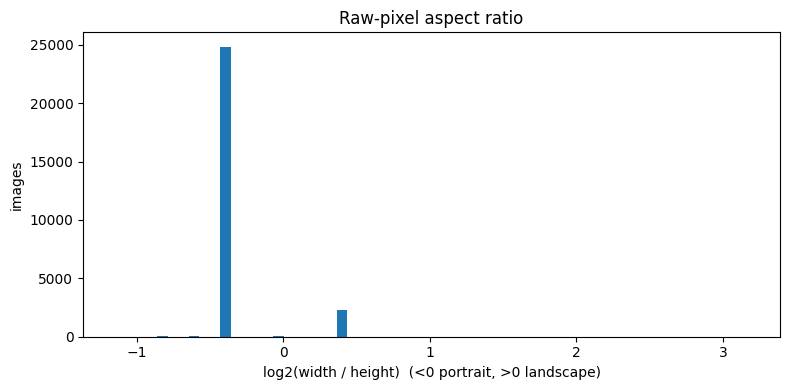

In [9]:
if props is not None:
    sizes = rp.file_size_summary(props)
    shapes = ip.shape_by_orientation(props)
    display(sizes, shapes)
    show(rp.plot_aspect(props), "eda_aspect")
    sections.append(("Aspect ratio and file size (train + val)",
                     "Raw pixel shape by EXIF orientation:\n\n" + rp.df_to_markdown(shapes)
                     + "\n\n" + rp.df_to_markdown(sizes)
                     + "\n\n" + figure_link("eda_aspect")))

### 2.3 ROT shortcut check (train)
Can ROT be predicted from raw pixel shape alone, with no image content? AP is compared with ROT
prevalence (the AP of a random guess). The "orientation 1 only" row removes the EXIF-tag-6 images,
so it shows whether shape carries signal beyond standing in for the tag.

In [10]:
if props is not None:
    train_props = props[props["partition"] == "train"]
    train_votes = lb.vote_matrix(train)
    rot_table = ip.rot_shortcut_table(train_props, train_votes)
    rot_scores = ip.rot_shortcut_scores(train_props, train_votes)
    display(rot_table, rot_scores)
    sections.append(("ROT shortcut check (train, ROT >=2 votes)",
                     "ROT rate by EXIF orientation x raw pixel shape:\n\n"
                     + rp.df_to_markdown(rot_table)
                     + "\n\nGeometry-only cues scored as ROT predictors:\n\n"
                     + rp.df_to_markdown(rot_scores)))

n  rot_rate
orientation shape                           
1           landscape          118       3.4
            portrait/square  21365      13.8
6           landscape         1948      53.4

,n,cue on %,ROT prevalence %,AP,ROT % | cue on,ROT % | cue off
landscape-shaped pixels (all images),23431.0,8.8,17.0,0.258,50.5,13.8
EXIF orientation 6 (all images),23431.0,8.3,17.0,0.265,53.4,13.7
landscape-shaped pixels (orientation 1 only),21483.0,0.5,13.7,0.137,3.4,13.8


## Write the report

In [11]:
out = rp.write_report(REPORT_PATH, sections)
print("Report written to", out)

Report written to /content/drive/MyDrive/Masters/Sem 3/capstone/repo/reports/eda.md
